# Answers - Cellpose

### First run the main notebook

In [1]:
%%capture
%run './02_cellpose.ipynb'

## Exercise: What happens when you change the diameter?


diameter  30 ->  55 objects
diameter  60 ->  37 objects
diameter  80 ->  35 objects
diameter 120 ->  31 objects


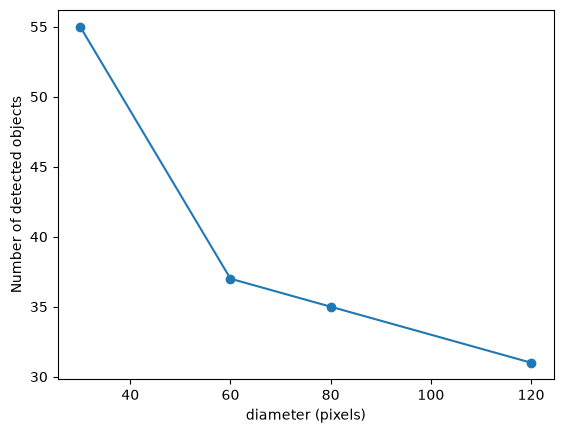

In [2]:
diameters = [30, 60, 80, 120]
masks_per_diameter = {}

for d in diameters:
    m, _, _ = model_nuc.eval(img_nuclei, channels=[0, 0], diameter=d)
    masks_per_diameter[d] = m
    print(f"diameter {d:3d} -> {m.max():3d} objects")

_ = plt.plot(diameters, [masks_per_diameter[d].max() for d in diameters], "o-")
_ = plt.xlabel("diameter (pixels)")
_ = plt.ylabel("Number of detected objects")

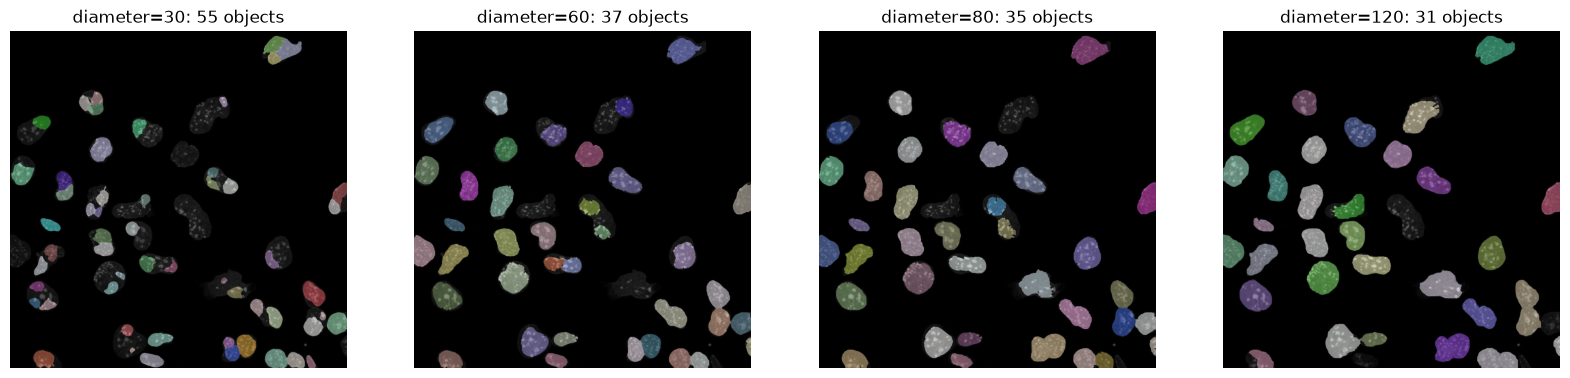

In [3]:
# We can plot it like this
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
for ax, d in zip(axs, diameters):
    _ = ax.imshow(img_nuclei, cmap="gray")
    _ = ax.imshow(masks_per_diameter[d], cmap=lbl_cmap, alpha=0.5)
    _ = ax.set_title(f"diameter={d}: {masks_per_diameter[d].max()} objects")
    _ = ax.axis("off")

- Too small (30, which is also the default): nuclei are cut into pieces, just like
  StarDist at `scale=1`.
- Too large (120): fewer objects, because small nuclei are missed or neighbours merge.
- Between 60 and 80 the result is stable.

The two parameters work in opposite directions: a larger Cellpose diameter and a smaller
StarDist scale both mean the image is shrunk more before it reaches the network.

## Exercise: Do StarDist and Cellpose find the same nuclei?

We redo the StarDist prediction here and put the two results next to each other.

In [4]:
from stardist.models import StarDist2D
from csbdeep.utils import normalize

model_sd = StarDist2D.from_pretrained("2D_versatile_fluo")
labels_sd, _ = model_sd.predict_instances(normalize(img_nuclei, 1, 99.8), scale=0.5)

print(f"StarDist: {labels_sd.max()} nuclei")
print(f"Cellpose: {masks_nuclei.max()} nuclei")

I0000 00:00:1789828123.899371  225629 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789828123.946837  225629 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789828125.686831  225629 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789828125.687389  225629 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will 

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.


E0000 00:00:1789828126.273052  225629 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
StarDist: 38 nuclei
Cellpose: 35 nuclei


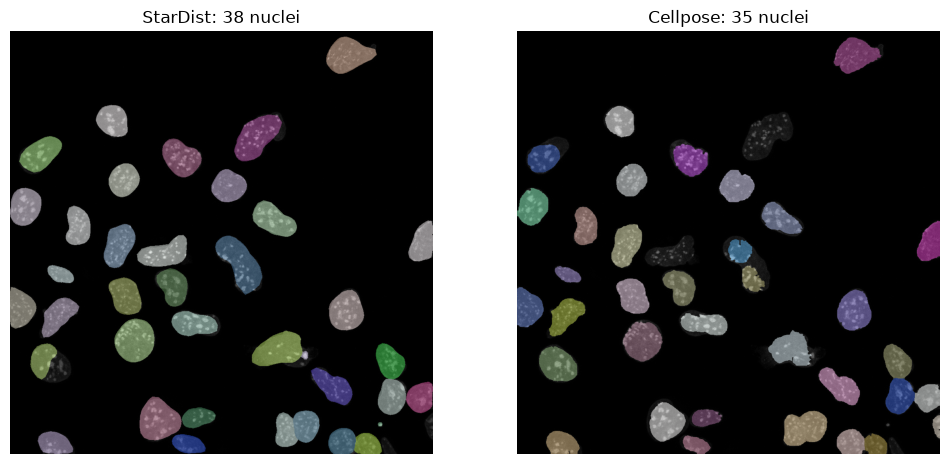

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
_ = axs[0].imshow(img_nuclei, cmap="gray")
_ = axs[0].imshow(labels_sd, cmap=lbl_cmap, alpha=0.5)
_ = axs[0].set_title(f"StarDist: {labels_sd.max()} nuclei")
_ = axs[1].imshow(img_nuclei, cmap="gray")
_ = axs[1].imshow(masks_nuclei, cmap=lbl_cmap, alpha=0.5)
_ = axs[1].set_title(f"Cellpose: {masks_nuclei.max()} nuclei")
for ax in axs:
    _ = ax.axis("off")

The two methods find nearly the same nuclei, and the outlines differ by a few pixels.
StarDist finds a few more objects than Cellpose: some of those are nuclei that Cellpose
missed, and a few are small objects that are not nuclei. Those could be filtered out.

For counting foci per nucleus these shape differences do not matter much. For measuring
nuclear area or intensity they can, so it is worth looking at the overlays before
choosing one.